# REINFORCE: The Original Policy Gradient Algorithm

**A hands-on tutorial with theory and PyTorch implementation**

---

**REINFORCE** ([Williams, 1992](https://link.springer.com/article/10.1007/BF00992696)) is the founding algorithm of the
*policy gradient* family. Where dynamic programming and Q-learning learn a *value function* and derive the policy
from it, REINFORCE does something radically simpler: it parameterizes the policy directly, $\pi_\theta(a \mid s)$, and
climbs the gradient of expected return with respect to $\theta$.

That idea — *optimize the policy directly, using the likelihood-ratio trick to get an unbiased gradient from samples* —
is the ancestor of A2C/A3C, TRPO, PPO, and therefore of the RLHF pipelines used to fine-tune modern large language
models. Every one of those is "REINFORCE plus variance reduction". Understanding REINFORCE means understanding what all
the later machinery is *for*.

## What you will learn

1. The **likelihood-ratio (score-function) trick** and the **policy gradient theorem**.
2. Why the naive estimator has enormous **variance**, and the two classic fixes: **reward-to-go** (causality) and
   a **baseline**.
3. A **from-scratch PyTorch implementation** on `CartPole-v1`, comparing the three estimators head-to-head.
4. An empirical measurement of gradient variance for each estimator.
5. How REINFORCE connects to actor-critic, PPO and RLHF.

## Notebook outline

1. Policy-based RL and the objective
2. Deriving the policy gradient
3. Variance reduction: reward-to-go and baselines
4. Implementation
5. Experiment: three estimators on CartPole
6. Measuring gradient variance
7. **Visual demonstration** of the trained agent
8. Strengths, weaknesses & connections
9. References

## 0. Setup

We use PyTorch for function approximation, `gymnasium` (the maintained fork of OpenAI Gym) for environments,
`pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs. If you don't have these installed,
uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import math
import random
import time
import warnings
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}, gymnasium version: {gym.__version__}")

Using device: cpu
PyTorch version: 2.11.0, gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

## 1. Policy-Based RL and the Objective

We parameterize a stochastic policy $\pi_\theta(a \mid s)$ — here, a small neural network that outputs action
probabilities — and seek parameters maximizing the **expected return**

$$
J(\theta) \;=\; \mathbb{E}_{\tau \sim \pi_\theta}\big[R(\tau)\big], \qquad R(\tau) = \sum_{t=0}^{T-1} \gamma^t r_t ,
$$

where a trajectory $\tau = (s_0, a_0, r_0, s_1, \ldots)$ is generated by the policy interacting with the environment.

Why optimize the policy directly rather than a value function?

- **Continuous and high-dimensional actions** are natural (output the parameters of a Gaussian).
- **Stochastic policies** can be optimal in partially observable or adversarial settings; a greedy $\arg\max_a Q$ cannot be.
- The gradient step changes action probabilities **smoothly**, whereas a tiny change in $Q$ can flip the greedy action.
- Prior knowledge is easy to inject via the policy architecture.

The catch: we cannot differentiate $J(\theta)$ through the environment, since $\tau$ depends on $\theta$ only through
*sampling*. The next section is the trick that gets around this.

## 2. Deriving the Policy Gradient

### 2.1 The likelihood-ratio (score-function) trick

Write $J(\theta) = \int p_\theta(\tau)\, R(\tau)\, d\tau$. Using $\nabla_\theta p_\theta = p_\theta \nabla_\theta \log p_\theta$:

$$
\nabla_\theta J(\theta) \;=\; \int p_\theta(\tau)\, \nabla_\theta \log p_\theta(\tau)\, R(\tau)\, d\tau
\;=\; \mathbb{E}_{\tau \sim \pi_\theta}\big[\nabla_\theta \log p_\theta(\tau)\, R(\tau)\big].
$$

The expectation is again over trajectories sampled from $\pi_\theta$, so we can estimate it with samples — that's the
whole trick.

### 2.2 The environment dynamics cancel out

The trajectory probability factorizes as
$p_\theta(\tau) = \rho_0(s_0) \prod_t \pi_\theta(a_t|s_t)\, P(s_{t+1}|s_t, a_t)$. Taking the log turns the product into a sum,
and the *dynamics terms do not depend on $\theta$*, so their gradient vanishes:

$$
\nabla_\theta \log p_\theta(\tau) \;=\; \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t \mid s_t).
$$

This is why policy gradient methods are **model-free**: we never need $P$.

### 2.3 REINFORCE

Putting it together, the **REINFORCE** gradient estimator from $N$ sampled trajectories is

$$
\boxed{\,\hat g \;=\; \frac{1}{N}\sum_{i=1}^{N} \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta\big(a^{(i)}_t \mid s^{(i)}_t\big)\; R\big(\tau^{(i)}\big)\,}
$$

and the update is gradient *ascent*: $\theta \leftarrow \theta + \alpha\, \hat g$. Intuition: the score
$\nabla_\theta \log \pi_\theta(a_t|s_t)$ points in the direction that makes $a_t$ *more likely*; we scale it by the
return, so actions from good trajectories are reinforced and actions from bad trajectories are suppressed.
Williams called this class of algorithms **RE**ward **I**ncrement $=$ **N**onnegative **F**actor $\times$ **O**ffset
**R**einforcement $\times$ **C**haracteristic **E**ligibility.

The estimator is **unbiased** — but its variance is terrible, for two reasons that we fix next.

## 3. Variance Reduction

### 3.1 Reward-to-go (exploiting causality)

In the estimator above, the score of action $a_t$ is multiplied by the *whole* trajectory return, including rewards
earned *before* $t$. But an action cannot affect the past. Those earlier rewards are just noise, and since
$\mathbb{E}[\nabla_\theta \log \pi_\theta(a_t|s_t)] = 0$ they contribute zero in expectation. Dropping them gives the
**reward-to-go** estimator:

$$
\hat g \;=\; \frac{1}{N}\sum_{i}\sum_{t} \nabla_\theta \log \pi_\theta(a^{(i)}_t \mid s^{(i)}_t)\; \underbrace{\sum_{t'=t}^{T-1} \gamma^{t'-t} r^{(i)}_{t'}}_{G^{(i)}_t}.
$$

Same expectation, strictly lower variance. This is the form that the **policy gradient theorem**
(Sutton et al., 2000) gives in general: $\nabla_\theta J = \mathbb{E}\big[\sum_t \nabla_\theta \log \pi_\theta(a_t|s_t)\, Q^{\pi}(s_t, a_t)\big]$.

### 3.2 Baselines

Subtracting any function of the state, $b(s_t)$, from the weight leaves the expectation unchanged:

$$
\mathbb{E}_{a_t \sim \pi_\theta}\big[\nabla_\theta \log \pi_\theta(a_t|s_t)\, b(s_t)\big] \;=\; b(s_t) \nabla_\theta \sum_a \pi_\theta(a|s_t) \;=\; b(s_t)\, \nabla_\theta 1 \;=\; 0 .
$$

Yet a good baseline drastically reduces variance. The natural choice is the state value $b(s_t) = V^\pi(s_t)$, which
turns the weight into an estimate of the **advantage** $A(s_t, a_t) = G_t - V(s_t)$: "was this action better or worse
than what I usually get from here?" We learn $V_\phi(s)$ with a second network by regressing on the observed returns.

$$
\boxed{\,\hat g \;=\; \frac{1}{N}\sum_{i}\sum_{t} \nabla_\theta \log \pi_\theta(a^{(i)}_t \mid s^{(i)}_t)\; \big(G^{(i)}_t - V_\phi(s^{(i)}_t)\big)\,}
$$

This is REINFORCE *with baseline* (Sutton & Barto §13.4). It is already very close to an actor-critic method — the
difference is that here $V_\phi$ is only used as a baseline, never to bootstrap.

In practice, almost everyone also **normalizes** the weights across the batch (zero mean, unit variance). It introduces
a slight bias but makes the effective learning rate independent of the reward scale — and, because subtracting the
batch mean is itself a crude baseline, it hides much of the difference between the estimators. For the head-to-head
comparison below we therefore leave normalization **off** (Adam's per-parameter scaling copes with the different
magnitudes); it is a one-line switch in the config.

## 4. Implementation

Components:

1. A **policy network** producing logits over the two CartPole actions.
2. A **value network** used as the baseline (only in the third variant).
3. A function to **collect a batch of complete episodes** — REINFORCE is a Monte Carlo method and needs full returns.
4. The **update** with the selected weighting: `"full_return"`, `"reward_to_go"`, or `"baseline"`.

In [4]:
@dataclass
class ReinforceConfig:
    env_id: str = "CartPole-v1"
    estimator: str = "baseline"     # "full_return" | "reward_to_go" | "baseline"
    episodes_per_update: int = 4    # N trajectories per gradient estimate
    total_episodes: int = 1000
    gamma: float = 0.99
    lr: float = 2e-3
    value_lr: float = 5e-3
    value_epochs: int = 5
    hidden: int = 64
    normalize_weights: bool = False  # batch-normalize the weights? (see the note in section 3)


class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(),
                                 nn.Linear(hidden, hidden), nn.Tanh(),
                                 nn.Linear(hidden, n_actions))

    def dist(self, obs):
        return torch.distributions.Categorical(logits=self.net(obs))


class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(),
                                 nn.Linear(hidden, hidden), nn.Tanh(),
                                 nn.Linear(hidden, 1))

    def forward(self, obs):
        return self.net(obs).squeeze(-1)

In [5]:
def discounted_rewards_to_go(rewards, gamma):
    """G_t = sum_{t' >= t} gamma^(t'-t) r_t', computed backwards."""
    G = np.zeros(len(rewards), dtype=np.float32)
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        G[t] = running
    return G


def collect_episodes(env, policy, n_episodes, gamma):
    """Run n complete episodes. Returns flat arrays of obs, actions, reward-to-go, full returns, and episode returns."""
    obs_buf, act_buf, rtg_buf, full_buf, ep_returns = [], [], [], [], []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        rewards, done = [], False
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
            with torch.no_grad():
                action = policy.dist(obs_t).sample().item()
            obs_buf.append(obs)
            act_buf.append(action)
            obs, r, terminated, truncated, _ = env.step(action)
            rewards.append(r)
            done = terminated or truncated
        rtg = discounted_rewards_to_go(rewards, gamma)
        rtg_buf.append(rtg)
        full_buf.append(np.full(len(rewards), rtg[0], dtype=np.float32))   # G_0 repeated for every step
        ep_returns.append(float(sum(rewards)))
    to_t = lambda x, dt=torch.float32: torch.as_tensor(np.concatenate(x) if isinstance(x[0], np.ndarray) else np.array(x), dtype=dt, device=device)
    return (to_t([np.array(obs_buf)]), to_t(act_buf, torch.long), to_t(rtg_buf), to_t(full_buf), ep_returns)


def train_reinforce(cfg: ReinforceConfig, seed=SEED, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env = gym.make(cfg.env_id)
    env.reset(seed=seed); env.action_space.seed(seed)
    obs_dim, n_actions = env.observation_space.shape[0], env.action_space.n

    policy = PolicyNet(obs_dim, n_actions, cfg.hidden).to(device)
    optimizer = torch.optim.Adam(policy.parameters(), lr=cfg.lr)
    value_fn = ValueNet(obs_dim, cfg.hidden).to(device)
    value_opt = torch.optim.Adam(value_fn.parameters(), lr=cfg.value_lr)

    history = []
    n_updates = cfg.total_episodes // cfg.episodes_per_update
    for update in range(1, n_updates + 1):
        obs, acts, rtg, full, ep_rets = collect_episodes(env, policy, cfg.episodes_per_update, cfg.gamma)

        # ---- choose the weight psi_t multiplying the score function ----
        if cfg.estimator == "full_return":
            weights = full
        elif cfg.estimator == "reward_to_go":
            weights = rtg
        elif cfg.estimator == "baseline":
            with torch.no_grad():
                weights = rtg - value_fn(obs)                       # advantage estimate G_t - V(s_t)
        else:
            raise ValueError(cfg.estimator)
        if cfg.normalize_weights:
            weights = (weights - weights.mean()) / (weights.std() + 1e-8)

        # ---- policy gradient step: maximize sum_t log pi(a_t|s_t) * psi_t ----
        logp = policy.dist(obs).log_prob(acts)
        loss = -(logp * weights).mean()
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        # ---- fit the baseline by regression on the returns ----
        if cfg.estimator == "baseline":
            for _ in range(cfg.value_epochs):
                v_loss = F.mse_loss(value_fn(obs), rtg)
                value_opt.zero_grad(); v_loss.backward(); value_opt.step()

        history.extend(ep_rets)
        if verbose and update % 25 == 0:
            print(f"[{cfg.estimator:12s}] episodes {update * cfg.episodes_per_update:5d} | mean return (last batch) {np.mean(ep_rets):6.1f}")
    env.close()
    return policy, value_fn, history

**Implementation notes**

- The whole update is one line: `loss = -(logp * weights).mean()`. Autograd computes $\sum_t \nabla_\theta \log \pi_\theta(a_t|s_t)\, \psi_t$ for us;
  the minus sign turns gradient *ascent* on $J$ into gradient *descent* on the loss.
- We average over *all timesteps in the batch* instead of summing per trajectory — a constant factor absorbed by the learning rate.
- Episodes are collected with `torch.no_grad()`; only the final batched forward pass builds a graph.
- Because REINFORCE needs complete episodes, we cannot use a fixed-size rollout buffer as in PPO; we just run $N$ episodes.

## 5. Experiment: Three Estimators on CartPole

Same seed, same number of episodes, same learning rate, no weight normalization — only the weighting $\psi_t$ differs.

In [6]:
results = {}
for estimator in ["full_return", "reward_to_go", "baseline"]:
    cfg = ReinforceConfig(estimator=estimator)
    t0 = time.time()
    policy, value_fn, hist = train_reinforce(cfg, verbose=False)
    results[estimator] = dict(policy=policy, value_fn=value_fn, history=hist)
    print(f"{estimator:12s}: {time.time() - t0:5.1f}s, mean return over the last 100 episodes = {np.mean(hist[-100:]):.1f}")

full_return :   3.9s, mean return over the last 100 episodes = 200.1


reward_to_go:  14.3s, mean return over the last 100 episodes = 427.4


baseline    :  23.1s, mean return over the last 100 episodes = 494.9


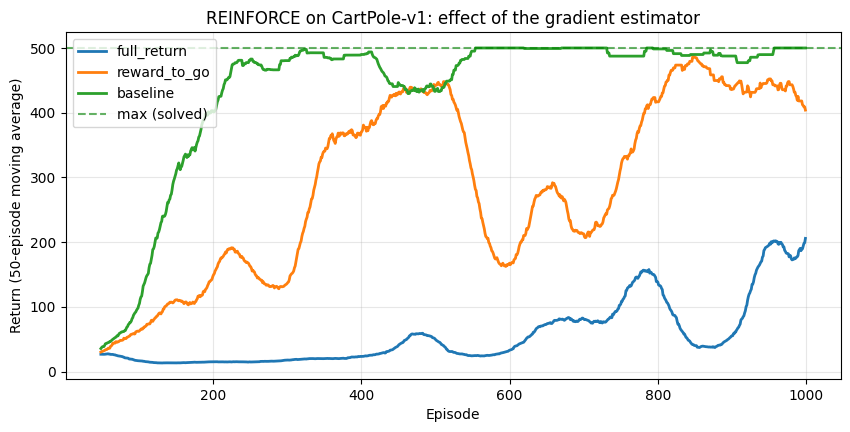

In [7]:
plt.figure(figsize=(10, 4.5))
for estimator, res in results.items():
    h = np.asarray(res["history"])
    smooth = np.convolve(h, np.ones(50) / 50, mode="valid")
    plt.plot(np.arange(len(smooth)) + 49, smooth, lw=2, label=estimator)
plt.axhline(500, color="green", ls="--", alpha=0.6, label="max (solved)")
plt.xlabel("Episode"); plt.ylabel("Return (50-episode moving average)")
plt.title("REINFORCE on CartPole-v1: effect of the gradient estimator")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Reading the plot.** All three estimators are unbiased and all three improve, but the learning speed is ordered by
variance: the full-return estimator is the noisiest and slowest, reward-to-go is much better, and adding a learned
baseline is better still. (Single-seed curves in RL are noisy; rerunning with another seed shifts the curves, but the
ordering is robust. With `normalize_weights=True` all three become fast on CartPole — normalization is a strong
variance reducer in its own right.)

## 6. Measuring Gradient Variance

We can measure the variance directly. Freeze a *partially trained* policy, draw many independent small batches, compute
the gradient estimate for each batch with each weighting, and look at the spread around the mean. The value baseline
is fit to the frozen policy first, so the comparison is fair.

In [8]:
def flat_grad(policy, obs, acts, weights):
    policy.zero_grad()
    logp = policy.dist(obs).log_prob(acts)
    (-(logp * weights).mean()).backward()
    return torch.cat([p.grad.flatten() for p in policy.parameters()]).detach().cpu().numpy()


# Freeze a mid-training policy: train the baseline variant briefly
probe_cfg = ReinforceConfig(estimator="reward_to_go", total_episodes=200, normalize_weights=True)
probe_policy, _, _ = train_reinforce(probe_cfg, seed=7, verbose=False)
probe_env = gym.make("CartPole-v1"); probe_env.reset(seed=123)

# Fit a value baseline for this frozen policy
probe_value = ValueNet(4, 64).to(device)
v_opt = torch.optim.Adam(probe_value.parameters(), lr=5e-3)
obs, acts, rtg, full, _ = collect_episodes(probe_env, probe_policy, 200, 0.99)
for _ in range(300):
    v_loss = F.mse_loss(probe_value(obs), rtg); v_opt.zero_grad(); v_loss.backward(); v_opt.step()

# Gradient samples (no normalization here, so we measure the raw estimators)
n_batches, batch_eps = 40, 4
grads = {"full_return": [], "reward_to_go": [], "baseline": []}
for _ in range(n_batches):
    obs, acts, rtg, full, _ = collect_episodes(probe_env, probe_policy, batch_eps, 0.99)
    with torch.no_grad():
        adv = rtg - probe_value(obs)
    grads["full_return"].append(flat_grad(probe_policy, obs, acts, full))
    grads["reward_to_go"].append(flat_grad(probe_policy, obs, acts, rtg))
    grads["baseline"].append(flat_grad(probe_policy, obs, acts, adv))

print(f"Gradient estimates from {n_batches} batches of {batch_eps} episodes, frozen policy (mean return ~{np.mean(_):.0f}):")
print(f"{'estimator':14s} {'||mean grad||':>14s} {'total variance':>16s} {'variance / ||mean||^2':>22s}")
for name, g in grads.items():
    g = np.stack(g)
    mean = g.mean(0)
    total_var = g.var(0, ddof=1).sum()
    print(f"{name:14s} {np.linalg.norm(mean):14.3f} {total_var:16.3f} {total_var / (np.linalg.norm(mean) ** 2):22.1f}")

Gradient estimates from 40 batches of 4 episodes, frozen policy (mean return ~129):
estimator       ||mean grad||   total variance  variance / ||mean||^2
full_return             2.830           53.911                    6.7
reward_to_go            2.934           20.925                    2.4
baseline                2.474            3.053                    0.5


The *direction* of the mean gradient is roughly the same for all three (they estimate the same quantity), but the
noise around it — the total variance — drops by a large factor from full-return to reward-to-go to baseline. This is
the entire reason later algorithms introduced critics, GAE and trust regions: the signal is fine, the noise is the problem.

## 7. Visual Demonstration

Let's watch the best-performing policy balance the pole. We evaluate greedily (most likely action) — a common choice for
demos — and record one episode.

Using the 'baseline' policy
Greedy evaluation over 10 episodes: mean 500.0, min 500, max 500


Recorded episode: return 500, length 500


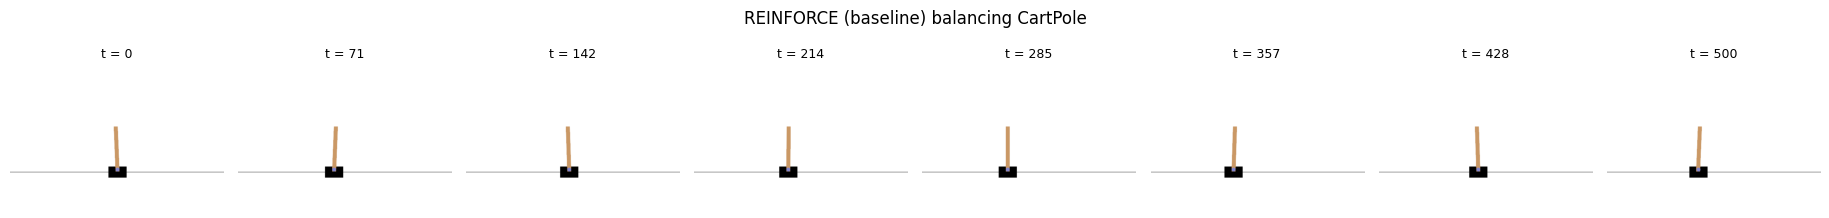

In [9]:
best_name = max(results, key=lambda k: np.mean(results[k]["history"][-100:]))
best_policy = results[best_name]["policy"]
print(f"Using the '{best_name}' policy")

def greedy_action(obs):
    with torch.no_grad():
        logits = best_policy.net(torch.as_tensor(obs, dtype=torch.float32, device=device))
    return int(logits.argmax().item())

eval_env = gym.make("CartPole-v1")
eval_returns = []
for i in range(10):
    obs, _ = eval_env.reset(seed=1000 + i); done, ep_ret = False, 0.0
    while not done:
        obs, r, terminated, truncated, _ = eval_env.step(greedy_action(obs)); ep_ret += r; done = terminated or truncated
    eval_returns.append(ep_ret)
print(f"Greedy evaluation over 10 episodes: mean {np.mean(eval_returns):.1f}, min {np.min(eval_returns):.0f}, max {np.max(eval_returns):.0f}")

render_env = gym.make("CartPole-v1", render_mode="rgb_array")
frames, ep_ret, ep_len = record_episode(render_env, greedy_action, seed=0, max_steps=500)
render_env.close()
print(f"Recorded episode: return {ep_ret:.0f}, length {ep_len}")
show_filmstrip(frames, n=8, title=f"REINFORCE ({best_name}) balancing CartPole")

Saved media/reinforce_cartpole.gif  (167 frames, 0.06 MB)


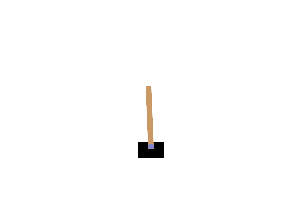

In [10]:
save_gif(frames, "reinforce_cartpole", fps=30)

## 8. Strengths, Weaknesses & Connections

### Strengths

- **Conceptually minimal.** One unbiased gradient estimator, one line of loss. Everything else in policy-gradient RL is
  optional machinery on top.
- **General.** Works with any differentiable policy — discrete, continuous, autoregressive (e.g. a language model
  generating tokens), recurrent.
- **Model-free and on-policy correct.** No dynamics model, no bootstrapping bias, no deadly triad.

### Weaknesses

- **Variance.** Even with reward-to-go and a baseline, the Monte Carlo return is noisy; long-horizon tasks are very slow.
- **Sample inefficiency.** Every trajectory is used for one gradient step and then discarded (on-policy). Off-policy
  reuse requires importance sampling, which blows up the variance further.
- **No step-size control.** A large step can collapse the policy, and because the next batch is collected *by that
  policy*, recovery is hard. TRPO and PPO exist to solve exactly this.
- **Needs complete episodes** — impossible in continuing tasks without truncation.

### Connections

- **Actor-critic / A2C**: replace $G_t$ with a bootstrapped $n$-step return $r_t + \ldots + \gamma^n V(s_{t+n})$. Lower
  variance, some bias, and no need to wait for the episode to end.
- **GAE** (Schulman et al., 2016): the systematic bias–variance dial between REINFORCE ($\lambda = 1$) and one-step TD ($\lambda = 0$).
- **TRPO / PPO**: REINFORCE with importance sampling for data reuse and a trust region / clipping for step-size control.
- **RLHF for LLMs**: the policy is a language model, the "action" is a token, the "trajectory" is a response, and the
  return is a reward-model score. **RLOO** and **GRPO** (DeepSeek-R1) are literally REINFORCE with a *group baseline*:
  sample several responses to a prompt and use their mean reward as $b$ — no learned critic at all. REINFORCE is very much
  alive in 2025.

## 9. References

1. **Williams, R. J.** (1992). *Simple statistical gradient-following algorithms for connectionist reinforcement learning.* Machine Learning, 8, 229–256.
2. **Sutton, R. S., McAllester, D., Singh, S., & Mansour, Y.** (2000). *Policy gradient methods for reinforcement learning with function approximation.* NeurIPS.
3. **Greensmith, E., Bartlett, P. L., & Baxter, J.** (2004). *Variance reduction techniques for gradient estimates in reinforcement learning.* JMLR, 5.
4. **Sutton, R. S., & Barto, A. G.** (2018). *Reinforcement Learning: An Introduction* (2nd ed.), Chapter 13. MIT Press.
5. **Schulman, J., Moritz, P., Levine, S., Jordan, M., & Abbeel, P.** (2016). *High-dimensional continuous control using generalized advantage estimation.* ICLR.
6. **Ahmadian, A., et al.** (2024). *Back to basics: Revisiting REINFORCE style optimization for learning from human feedback in LLMs.* ACL (RLOO).
7. **Shao, Z., et al.** (2024). *DeepSeekMath: Pushing the limits of mathematical reasoning in open language models.* arXiv:2402.03300 (GRPO).